# Exercise 5

Design a graph-based workflow system that takes four numbers and performs two stages of arithmetic operations using conditional routing.

In the first stage, apply either addition or subtraction on `number1` and `number2` based on `operation`, storing the result as `finalNumber`.

In the second stage, apply the same logic on `number3` and `number4` based on `operation2`, storing the result as `finalNumber2`.

The system must use a graph-based execution flow where routing nodes decide which operation node to execute.

---

### Sample Input
```python
{
    "number1": 10,
    "number2": 5,
    "number3": 7,
    "number4": 2,
    "operation": "-",
    "operation2": "+"
}
```

/home/rakib/miniconda3/envs/langgraph/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


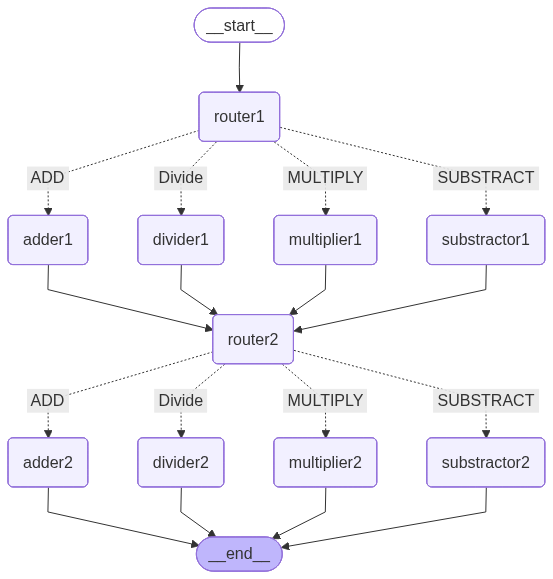

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
{
    "RESULT": {
        "num1": 1,
        "num2": 2,
        "num3": 3,
        "num4": 4,
        "opt1": "+",
        "opt2": "-",
        "final1": 3,
        "final2": -1
    }
}
####################################################################################################


In [1]:
from typing import TypedDict, Literal, Union
from langgraph.graph import StateGraph, START, END
from tools.VGraph import Helper

__tools__ = Helper()

class Agent5(TypedDict):
    num1: float
    num2: float
    num3: float
    num4: float
    opt1: Literal["+", "-", "*", "/"]
    opt2: Literal["+", "-", "*", "/"]
    final1: float
    final2: float

def add1(state: Agent5) -> Agent5:
    state["final1"] = state["num1"] + state["num2"]
    return state

def subs1(state: Agent5) -> Agent5:
    state["final1"] = state["num1"] - state["num2"]
    return state

def multi1(state: Agent5) -> Agent5:
    state["final1"] = state["num1"] * state["num2"]
    return state

def div1(state: Agent5) -> Agent5:
    state["final1"] = state["num1"] / state["num2"]
    return state

def router1(state: Agent5) -> str:
    if state["opt1"] == "+":
        return "ADD"
    elif state["opt1"] == "-":
        return "SUBSTRACT"
    elif state["opt1"] == "*":
        return "MULTIPLY"
    elif state["opt1"] == "/":
        return "Divide"



def add2(state: Agent5) -> Agent5:
    state["final2"] = state["num3"] + state["num4"]
    return state

def subs2(state: Agent5) -> Agent5:
    state["final2"] = state["num3"] - state["num4"]
    return state

def multi2(state: Agent5) -> Agent5:
    state["final2"] = state["num3"] * state["num4"]
    return state

def div2(state: Agent5) -> Agent5:
    state["final2"] = state["num3"] / state["num4"]
    return state


def router2(state: Agent5) -> str:
    if state["opt2"] == "+":
        return "ADD"
    elif state["opt2"] == "-":
        return "SUBSTRACT"
    elif state["opt2"] == "*":
        return "MULTIPLY"
    elif state["opt2"] == "/":
        return "Divide"



graph = StateGraph(Agent5)

graph.add_node("adder1", add1)
graph.add_node("substractor1", subs1)
graph.add_node("multiplier1", multi1)
graph.add_node("divider1", div1)
graph.add_node("router1", lambda x:x)

graph.add_node("adder2", add2)
graph.add_node("substractor2", subs2)
graph.add_node("multiplier2", multi2)
graph.add_node("divider2", div2)
graph.add_node("router2", lambda x:x)

graph.add_edge(START, "router1")
graph.add_conditional_edges(
    source="router1",
    path=router1,
    path_map={
        "ADD": "adder1",
        "SUBSTRACT": "substractor1",
        "MULTIPLY": "multiplier1",
        "Divide": "divider1"
    }
)

graph.add_edge("adder1", "router2")
graph.add_edge("substractor1", "router2")
graph.add_edge("multiplier1", "router2")
graph.add_edge("divider1", "router2")
graph.add_conditional_edges(
    source="router2",
    path=router2,
    path_map={
        "ADD": "adder2",
        "SUBSTRACT": "substractor2",
        "MULTIPLY": "multiplier2",
        "Divide": "divider2"
    }
)
graph.add_edge("adder2", END)
graph.add_edge("substractor2", END)
graph.add_edge("multiplier2", END)
graph.add_edge("divider2", END)



app = graph.compile()

__tools__.view_graph(app)


res = app.invoke(
    {
        "num1": 1,
        "num2": 2,
        "num3": 3,
        "num4": 4,
        "opt1": "+",
        "opt2": "-"
    }
)


__tools__.monitor({"RESULT": res})

